# Short-term stock market prediction with Time Series Transformer Network	

In [79]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import sampler
import torch.optim as optim

from sklearn.model_selection import train_test_split

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
USE_GPU = True
device=None
dtype = torch.float32 # we will be using float throughout this tutorial

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('using device:', device)
# print(torch.cuda.device_count())
# print(torch.cuda.get_device_name(0))

using device: cuda


In [5]:
data_all = pd.read_csv("datasets/Kaggle_Dow_Jones_30_Historical_Data.csv")
data_all.replace('?', 0, inplace=True)
data_all.replace(np.nan, 0, inplace=True)

In [ ]:
#data_all.isnull().values.any()

data_all.isnull().any() #check for any NaN

#nan_rows = data_all[data_all['Walmart'].isnull()]
#data_all.columns

#DEBUG
#nans = test_data.isin([nan])

Date                 False
MMM                  False
American Express     False
Boeing               False
Caterpillar          False
Coca Cola            False
IBM                  False
Intel                False
J&J                  False
JPMorgan             False
McDonalds            False
Merck & Co.          False
Microsoft            False
Procter & Gamble     False
The Home Depot       False
Walmart              False
Walt Disney          False
DJIA                 False
dtype: bool

In [ ]:
window_length=12 
pred_length=6 #make len even to keep things simpler
batch_size = 1024#512 #too big?

#split into train and test datasets
split = 5700
train_data = data_all.iloc[:split, :]
test_data = data_all.iloc[split:, :] 

def preprocess(data, window_length = window_length, pred_length = pred_length):
    #flatten all stocks into one column  
    data = data.iloc[:, 1:].melt()
    data = data.iloc[:, 1]
    
    data = pd.to_numeric(data).to_numpy() #faster to do slicing operation as numpy array than pandas
    time_length = data.size

    #split into sections of length window_length, normalize, then put first half in x and second half in y
    x = [] 
    y = []
    for window_index in np.arange( np.random.randint(0,window_length-1), time_length-window_length-pred_length, window_length):  
        window = np.array(data[window_index:window_index+window_length])
        window = window-np.min(window) 
        window = window/np.max(window)

        x.append(window[0:pred_length])
        y.append(window[pred_length:window_length])
     
    x = np.asarray(x)
    y = np.asarray(y)

    #add positional enccoding
    x = np.reshape(x, [x.shape[0], x.shape[1], 1])#reshape into N, S, E where S is the source sequence length, T is the target sequence length, N is the batch size, EE is the feature number
    y = np.reshape(y, [y.shape[0], y.shape[1], 1]) 

    dim_model = 1 #number of features
    max_len = pred_length 

    position_encoding = np.zeros([max_len, dim_model], dtype=np.float32)
    position_list = np.reshape(np.arange(0, max_len, dtype=np.float32), [-1, 1])
    denominator = np.exp(-np.log(10000.0) * np.arange(0, dim_model, 2, dtype=np.float32)/dim_model) 
    position_encoding[:, 0::2] = np.sin(position_list / denominator)
    position_encoding[:, 1::2] = np.cos(position_list / denominator)

    plt.imshow(position_encoding)
    plt.figure()

    x[0, :, 0] = position_encoding[:, 0] #replace 2nd dim with positional encodings
    y[0, :, 0] = position_encoding[:, 0]
    
    return x, y


x_train, y_train = preprocess(train_data)
x_test, y_test = preprocess(test_data)

# print(x_train.shape)
# print(y_train.shape)
# print(x_train.dtype)

train_loader = DataLoader(list(zip(x_train, y_train)), batch_size, shuffle=True) #x is same as y for simple scalar transformers, right?
test_loader = DataLoader(list(zip(x_train, y_train)), batch_size, shuffle=True)

In [157]:
print(x_test.shape)
print(x_test[:, 0, :])

(126, 6, 1)
[[0.        ]
 [0.        ]
 [0.91042254]
 [0.86      ]
 [1.        ]
 [0.25835189]
 [0.        ]
 [0.11895911]
 [0.57689178]
 [0.84785615]
 [0.        ]
 [0.56331007]
 [0.97656029]
 [0.        ]
 [0.        ]
 [1.        ]
 [0.12585034]
 [0.76498205]
 [0.        ]
 [1.        ]
 [0.        ]
 [0.        ]
 [0.14440154]
 [0.90177815]
 [0.03297609]
 [0.98492462]
 [0.88707124]
 [0.12971481]
 [0.04980341]
 [1.        ]
 [0.03723404]
 [0.        ]
 [0.52542373]
 [0.42352941]
 [0.16810345]
 [0.94642857]
 [0.        ]
 [0.02816901]
 [0.        ]
 [0.97400821]
 [0.05875706]
 [0.94640339]
 [0.5370019 ]
 [0.        ]
 [1.        ]
 [1.        ]
 [0.10045662]
 [1.        ]
 [0.37339056]
 [0.84834123]
 [0.82205514]
 [0.        ]
 [0.        ]
 [1.        ]
 [0.67013889]
 [0.19404517]
 [1.        ]
 [0.24360536]
 [0.34285714]
 [1.        ]
 [1.        ]
 [0.        ]
 [1.        ]
 [0.        ]
 [1.        ]
 [0.06354749]
 [0.54970898]
 [0.0203193 ]
 [0.55994152]
 [0.92835458]
 [0.4320

In [155]:
# window_size = 16
# forecast_length = 16
# num_val = 2

# data_all['date'] = pd.to_datetime(data_all['date']) #convert int to datetime
# val_max_date = '2017-08-15'
# train_max_date = str((pd.to_datetime(val_max_date) - pd.Timedelta(days=window_size*num_val+forecast_length)).date())

# train_final = data_all[data_all['date']<=train_max_date]
# val_final = data_all[(data_all['date']>train_max_date)&(data_all['date']<=val_max_date)]

# train_series = train_final.groupby(categorical_static).agg(list).reset_index()
# val_series = val_final.groupby(categorical_static).agg(list).reset_index()

# #try changing date to ints
# train_series
# data_all['date'] = pd.to_datetime(data_all['date']) #convert int to datetime

In [156]:
# def divide_shuffle(df,div_num):
#     space = df.shape[0]//div_num
#     division = np.arange(0,df.shape[0],space)
#     return pd.concat([df.iloc[division[i]:division[i]+space,:].sample(frac=1) for i in range(len(division))])

# def create_time_blocks(time_length,window_size,forecast_length):
#     start_idx = np.random.randint(0,window_size-1)
#     end_idx = time_length-window_size-forecast_length-1
#     time_indices = np.arange(start_idx,end_idx+1,window_size)[:-1]
#     time_indices = np.append(time_indices,end_idx)
#     return time_indices

# def data_loader(x_numeric_tensor, x_category_tensor, x_static_tensor, y_tensor, batch_size, time_shuffle):

#     num_series = x_numeric_tensor.shape[0]
#     time_length = x_numeric_tensor.shape[1]
#     index_pd = pd.DataFrame({'serie_idx':range(num_series)})
#     index_pd['time_idx'] = [create_time_blocks(time_length,window_size,forecast_length) for n in range(index_pd.shape[0])]
#     if time_shuffle:
#         index_pd = index_pd.explode('time_idx')
#         index_pd = index_pd.sample(frac=1)
#     else:
#         index_pd = index_pd.explode('time_idx').sort_values('time_idx')
#         index_pd = divide_shuffle(index_pd,5)
#     indices = np.array(index_pd).astype(int)

#     for batch_idx in np.arange(0,indices.shape[0],batch_size):

#         cur_indices = indices[batch_idx:batch_idx+batch_size,:]

#         x_numeric = torch.stack([x_numeric_tensor[n[0],n[1]:n[1]+window_size,:] for n in cur_indices])
#         x_category = torch.stack([x_category_tensor[n[0],n[1]:n[1]+window_size,:] for n in cur_indices])
#         x_static = torch.stack([x_static_tensor[n[0],:] for n in cur_indices])
#         y = torch.stack([y_tensor[n[0],n[1]+window_size:n[1]+window_size+forecast_length] for n in cur_indices])

#         yield x_numeric.to(device), x_category.to(device), x_static.to(device), y.to(device)

# def val_loader(x_numeric_tensor, x_category_tensor, x_static_tensor, y_tensor, batch_size, num_val):

#     num_time_series = x_numeric_tensor.shape[0]

#     for i in range(num_val):

#       for batch_idx in np.arange(0,num_time_series,batch_size):

#           x_numeric = x_numeric_tensor[batch_idx:batch_idx+batch_size,window_size*i:window_size*(i+1),:]
#           x_category = x_category_tensor[batch_idx:batch_idx+batch_size,window_size*i:window_size*(i+1),:]
#           x_static = x_static_tensor[batch_idx:batch_idx+batch_size]
#           y_val = y_tensor[batch_idx:batch_idx+batch_size,window_size*(i+1):window_size*(i+1)+forecast_length]

#           yield x_numeric.to(device), x_category.to(device), x_static.to(device), y_val.to(device)

In [ ]:
#medium model
#don't need to run this block
class transformer_block(nn.Module):

    def __init__(self,embed_size,num_heads):
        super(transformer_block, self).__init__()

        self.attention = nn.MultiheadAttention(embed_size, num_heads, batch_first=True)
        self.fc = nn.Sequential(nn.Linear(embed_size, 4 * embed_size),
                                 nn.LeakyReLU(),
                                 nn.Linear(4 * embed_size, embed_size))
        self.dropout = nn.Dropout(drop_prob)
        self.ln1 = nn.LayerNorm(embed_size, eps=1e-6)
        self.ln2 = nn.LayerNorm(embed_size, eps=1e-6)

    def forward(self, x):

        attn_out, _ = self.attention(x, x, x, need_weights=False)
        x = x + self.dropout(attn_out)
        x = self.ln1(x)

        fc_out = self.fc(x)
        x = x + self.dropout(fc_out)
        x = self.ln2(x)

        return x


class transformer_forecaster(nn.Module):

    def __init__(self,embed_size,num_heads,num_blocks):
        super(transformer_forecaster, self).__init__()

        num_len = len(numeric_covariates)
        self.embedding_cov = nn.ModuleList([nn.Embedding(n,embed_size-num_len) for n in categorical_covariates_num_embeddings])
        self.embedding_static = nn.ModuleList([nn.Embedding(n,embed_size-num_len) for n in categorical_static_num_embeddings])

        self.blocks = nn.ModuleList([transformer_block(embed_size,num_heads) for n in range(num_blocks)])

        self.forecast_head = nn.Sequential(nn.Linear(embed_size, embed_size*2),
                                           nn.LeakyReLU(),
                                           nn.Dropout(drop_prob),
                                           nn.Linear(embed_size*2, embed_size*4),
                                           nn.LeakyReLU(),
                                           nn.Linear(embed_size*4, forecast_length),
                                           nn.ReLU())

    def forward(self, x_numeric, x_category, x_static):

        tmp_list = []
        for i,embed_layer in enumerate(self.embedding_static):
            tmp_list.append(embed_layer(x_static[:,i]))
        categroical_static_embeddings = torch.stack(tmp_list).mean(dim=0).unsqueeze(1)

        tmp_list = []
        for i,embed_layer in enumerate(self.embedding_cov):
            tmp_list.append(embed_layer(x_category[:,:,i]))
        categroical_covariates_embeddings = torch.stack(tmp_list).mean(dim=0)
        T = categroical_covariates_embeddings.shape[1]

        embed_out = (categroical_covariates_embeddings + categroical_static_embeddings.repeat(1,T,1))/2
        x = torch.concat((x_numeric,embed_out),dim=-1)

        for block in self.blocks:
            x = block(x)

        x = x.mean(dim=1)
        x = self.forecast_head(x)

        return x
    



class RMSLELoss(nn.Module):

    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()

    def forward(self, pred, actual):
        return torch.sqrt(self.mse(torch.log(pred + 1), torch.log(actual + 1)))

In [158]:
#Pytorch vanilla transformer

transformer_model = nn.Transformer(d_model = 1, nhead=1, num_encoder_layers=6, num_decoder_layers=6, batch_first=True, device=device) #only 1 head bc of 1 input dimension
# src = torch.rand((batch_size, window_length, 1)).to(device=device, dtype=dtype)#10, 32, 512)) #replace w ...
# tgt = torch.rand((batch_size, pred_length, 1)).to(device=device, dtype=dtype)#20, 32, 512))
# out = transformer_model(src, tgt).to(device=device, dtype=dtype) #MOVE TO CPU DEVICE????
# print(src.dtype)

class RMSLELoss(nn.Module):

    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()

    def forward(self, pred, actual):
        return torch.sqrt(self.mse(torch.log(pred + 1), torch.log(actual + 1)))

c:\Users\ebook\Documents\1) School\0) UCSD\ECE 176\Final Project\.venv\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


In [159]:
#train the damn thing

num_epoch = 5#1000
min_val_loss = 1
data_folder = 'saved_models/'

learning_rate = 3.5e-5 #try smaller lr
time_shuffle = False
drop_prob = 0.1

model = transformer_model
criterion = RMSLELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

for epoch in range(num_epoch):
    
    model.train()
    train_loss = 0
    counter = 0
    mask = nn.Transformer.generate_square_subsequent_mask(sz=pred_length, device=device) #generate casual mask #WAIT.... DIFFERENT MASK SIZES NOT GIVING ERROR
    
    for x_batch, y_batch in train_loader: 
        x_batch = x_batch.to(device=device, dtype=dtype)
        y_batch = y_batch.to(device=device, dtype=dtype)
        optimizer.zero_grad()
        pred = model(x_batch, y_batch, src_mask=mask, tgt_mask=mask, src_is_causal=True, tgt_is_causal=True)  #is the the correct place to enter the forward() parameters?
        #pred = model(x_batch, y_batch)#, src_mask=mask, tgt_mask=mask, src_is_causal=True, tgt_is_causal=True)  #is the the correct place to enter the forward() parameters?
        loss = criterion(pred, y_batch)
        train_loss += loss.item()
        counter += 1
        loss.backward()
        optimizer.step()

    train_loss = train_loss/counter
    print(f'Epoch {epoch} training loss: {train_loss}')

    model.eval()
    val_loss = 0
    counter = 0
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device=device, dtype=dtype)
        y_batch = y_batch.to(device=device, dtype=dtype)
        with torch.no_grad():
            pred = model(x_batch, y_batch, src_mask=mask, tgt_mask=mask, src_is_causal=True, tgt_is_causal=True)
            #pred = model(x_batch, y_batch)#, src_mask=mask, tgt_mask=mask, src_is_causal=True, tgt_is_causal=True)  #is the the correct place to enter the forward() parameters?
            loss = criterion(pred,y_batch).item()
        val_loss += loss
        counter += 1
    val_loss = val_loss/counter
    print(f'Epoch {epoch} validation loss: {val_loss}')

    if val_loss<min_val_loss:
      print('saved...')
      torch.save(model,data_folder+'best.model')
      min_val_loss = val_loss

    scheduler.step()

Epoch 0 training loss: 0.464704904705286
Epoch 0 validation loss: 0.46447622030973434
saved...
Epoch 1 training loss: 0.4645067974925041
Epoch 1 validation loss: 0.46426062658429146
saved...
Epoch 2 training loss: 0.4641842693090439
Epoch 2 validation loss: 0.4640685021877289
saved...
Epoch 3 training loss: 0.46387871354818344
Epoch 3 validation loss: 0.46375250071287155
saved...
Epoch 4 training loss: 0.46363014355301857
Epoch 4 validation loss: 0.46361541002988815
saved...


In [212]:
# #save the model
# print("Model's state_dic:")
# for param_tensor in model.state_dic():
#     print(param_tensor, "\t", model.state_dict()[param_tensor].size())

# torch.save(model.state_dict(), 'saved_models/toy_model.pt')

In [160]:
#test the model
data_folder = 'saved_models/'
model = torch.load(data_folder+'best.model', weights_only=False)
                   
truth_plot_data = torch.empty((0,pred_length,1))       #save data for visualization
pred_plot_data = torch.empty((0,pred_length,1))  #save data for visualization
truth_plot_data = truth_plot_data.to(device=device, dtype=dtype)
pred_plot_data = pred_plot_data.to(device=device, dtype=dtype)

model.eval()
val_loss = 0
counter = 0
for x_batch, y_batch in test_loader:
    x_batch = x_batch.to(device=device, dtype=dtype)
    y_batch = y_batch.to(device=device, dtype=dtype)
    truth_plot_data = torch.cat((truth_plot_data, y_batch))
    with torch.no_grad():
        pred = model(x_batch, y_batch, src_mask=mask, tgt_mask=mask, src_is_causal=True, tgt_is_causal=True)
        #pred = model(x_batch, y_batch)#, src_mask=mask, tgt_mask=mask, src_is_causal=True, tgt_is_causal=True)  #is the the correct place to enter the forward() parameters?
        loss = criterion(pred,y_batch).item()
        pred_plot_data = torch.cat((pred_plot_data, pred))
    val_loss += loss
    counter += 1
val_loss = val_loss/counter
print(f'Test loss: {val_loss}')

truth_plot_data = truth_plot_data.cpu()
pred_plot_data = pred_plot_data.cpu()

Test loss: 0.4634707681834698


In [162]:
pred_plot_data.shape
pred_plot_data

tensor([[[0.0014],
         [0.0014],
         [0.0014],
         [0.0014],
         [0.0014],
         [0.0014]],

        [[0.0014],
         [0.0014],
         [0.0014],
         [0.0014],
         [0.0014],
         [0.0014]],

        [[0.0014],
         [0.0014],
         [0.0014],
         [0.0014],
         [0.0014],
         [0.0014]],

        ...,

        [[0.0014],
         [0.0014],
         [0.0014],
         [0.0014],
         [0.0014],
         [0.0014]],

        [[0.0014],
         [0.0014],
         [0.0014],
         [0.0014],
         [0.0014],
         [0.0014]],

        [[0.0014],
         [0.0014],
         [0.0014],
         [0.0014],
         [0.0014],
         [0.0014]]])

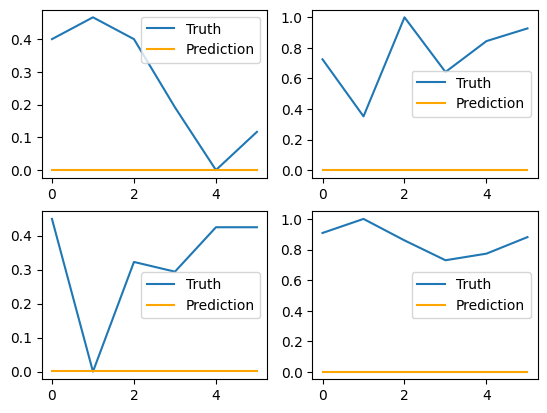

In [163]:
#truth_plot_data.shape
x_count = 2
y_count = 2
fig, axs = plt.subplots(x_count, y_count)

count = 0
for a in range(x_count):
    for b in range(y_count):
        axs[a, b].plot(truth_plot_data[count])
        axs[a, b].plot(pred_plot_data[count], 'orange')
        axs[a, b].legend(['Truth', 'Prediction'])
        count = count + 1